# Phase 4: ROI-Centric Evaluation — BraTS 2025

| Metric | Target | Scope |
|---|---|---|
| **SSIM** | ≥ 0.85 | Within ROI masks |
| **MSE** | ≤ 0.01 | Global + ROI |
| **HD95** | Minimize | ROI boundary |
| **DSC** | Maximize | Volumetric overlap |
| **KL Divergence** | Minimize | Safety gate |

In [43]:
import os,json,numpy as np,torch,torch.nn as nn,torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as _ssim
from scipy.ndimage import binary_erosion
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import csv

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROC_DIR=r"f:\shn\processed"
RESULTS=r"f:\shn\results"; os.makedirs(RESULTS, exist_ok=True)
MOD=1  # T1c modality index

---
## 1. Evaluation Metrics

In [44]:
# ═════════ 1. ROI-Localized SSIM ═════════
def roi_ssim(real,syn,mask,win_size=7):
    mask=mask.astype(bool)
    if mask.sum()==0: return -1.0
    _,smap=_ssim(real,syn,data_range=1.0,win_size=win_size,full=True)
    return float(smap[mask].mean())

def batch_ssim(reals,syns,masks):
    v=[roi_ssim(r,s,m) for r,s,m in zip(reals,syns,masks)]; v=[x for x in v if x>=0]
    a=np.array(v); return {"mean":float(a.mean()) if len(a) else 0,"std":float(a.std()) if len(a) else 0,"pass":bool(a.mean()>=0.85) if len(a) else False}

# ═════════ 2. MSE (Global + ROI) ═════════
def calc_mse(real,syn,mask=None):
    d=(real.astype(np.float64)-syn.astype(np.float64))**2
    g=float(d.mean()); r=float(d[mask.astype(bool)].mean()) if mask is not None and mask.astype(bool).sum()>0 else None
    return {"global":g,"roi":r}

def batch_mse(reals,syns,masks=None):
    gv,rv=[],[]
    for i in range(len(reals)):
        m=masks[i] if masks is not None else None; r=calc_mse(reals[i],syns[i],m)
        gv.append(r["global"])
        if r["roi"] is not None: rv.append(r["roi"])
    g=np.array(gv);r=np.array(rv) if rv else np.array([])
    return {"global":{"mean":float(g.mean()) if len(g) else 0,"std":float(g.std()) if len(g) else 0,"pass":bool(g.mean()<=0.01) if len(g) else False},
            "roi":{"mean":float(r.mean()) if len(r) else 0,"std":float(r.std()) if len(r) else 0,"pass":bool(r.mean()<=0.01) if len(r) else False}}

# ═════════ 3. HD95 ═════════
def hd95(mr,mp):
    mr=mr.astype(bool);mp=mp.astype(bool)
    if mr.sum()==0 or mp.sum()==0:return -1.0
    br=mr^binary_erosion(mr);bp=mp^binary_erosion(mp)
    cr=np.argwhere(br);cp=np.argwhere(bp)
    if len(cr)==0 or len(cp)==0:return -1.0
    return float(np.percentile(np.concatenate([cdist(cr,cp).min(1),cdist(cp,cr).min(1)]),95))
def batch_hd95(mr,mp):
    v=[hd95(a,b) for a,b in zip(mr,mp)];v=[x for x in v if x>=0];a=np.array(v)
    return {"mean":float(a.mean()) if len(a) else 0,"std":float(a.std()) if len(a) else 0}

# ═════════ 4. DSC ═════════
def dsc(mr,mp):
    mr=mr.astype(bool);mp=mp.astype(bool);i=(mr&mp).sum();t=mr.sum()+mp.sum()
    return float(2*i/t) if t>0 else 0.0
def batch_dsc(mr,mp):v=[dsc(a,b) for a,b in zip(mr,mp)];a=np.array(v);return {"mean":float(a.mean()) if len(a) else 0,"std":float(a.std()) if len(a) else 0}

# ═════════ 5. KL Divergence Safety ═════════
def kl_div(real,syn,mask=None,bins=256,eps=1e-10):
    if mask is not None:m=mask.astype(bool);real=real[m];syn=syn[m]
    else:real=real.ravel();syn=syn.ravel()
    if real.size==0:return -1.0
    b=np.linspace(0,1,bins+1)
    p,_=np.histogram(real,bins=b,density=True);q,_=np.histogram(syn,bins=b,density=True)
    p=p.astype(np.float64)+eps;q=q.astype(np.float64)+eps;p/=p.sum();q/=q.sum()
    return float(np.sum(p*np.log(p/q)))
def batch_kl(reals,syns,masks=None,th=0.1):
    v,uf=[],[]
    for i in range(len(reals)):
        m=masks[i] if masks is not None else None;k=kl_div(reals[i],syns[i],m)
        if k>=0:v.append(k)
        if k>th:uf.append(i)
    a=np.array(v);n=len(a)
    return {"mean":float(a.mean()) if n else 0,"safe_pct":float((n-len(uf))/n*100) if n else 0}

print("✓ All 5 metrics loaded.")

✓ All 5 metrics loaded.


---
## 2. Generator Architectures (for loading checkpoints)

In [45]:
# ══════════════ Shared blocks + all 4 generators ══════════════
class DepthwiseSeparableConv2d(nn.Module):
    def __init__(s,i,o,k=3,st=1,p=1,b=False):super().__init__();s.dw=nn.Conv2d(i,i,k,st,p,groups=i,bias=b);s.pw=nn.Conv2d(i,o,1,bias=b)
    def forward(s,x):return s.pw(s.dw(x))
class DSConvBlock(nn.Module):
    def __init__(s,i,o,k=3,s_=1,act="leaky_relu",bn=True):
        super().__init__()
        layers=[DepthwiseSeparableConv2d(i,o,k,s_,k//2)]
        if bn:layers.append(nn.BatchNorm2d(o))
        a={"relu":nn.ReLU(True),"leaky_relu":nn.LeakyReLU(0.2,True),"prelu":nn.PReLU(o),"none":nn.Identity()}
        layers.append(a.get(act,nn.LeakyReLU(0.2,True)));s.block=nn.Sequential(*layers)
    def forward(s,x):return s.block(x)
class ResidualDSBlock(nn.Module):
    def __init__(s,ch):super().__init__();s.block=nn.Sequential(DSConvBlock(ch,ch),DSConvBlock(ch,ch,act="none"))
    def forward(s,x):return x+s.block(x)

class VanillaGenerator(nn.Module):
    def __init__(s,in_ch=1,out_ch=1,bf=32):
        super().__init__()
        s.enc1=nn.Sequential(DSConvBlock(in_ch,bf),DSConvBlock(bf,bf),nn.MaxPool2d(2))
        s.enc2=nn.Sequential(DSConvBlock(bf,bf*2),DSConvBlock(bf*2,bf*2),nn.MaxPool2d(2))
        s.enc3=nn.Sequential(DSConvBlock(bf*2,bf*4),DSConvBlock(bf*4,bf*4),nn.MaxPool2d(2))
        s.enc4=nn.Sequential(DSConvBlock(bf*4,bf*8),DSConvBlock(bf*8,bf*8),nn.MaxPool2d(2))
        s.bottleneck=nn.Sequential(DSConvBlock(bf*8,bf*8),DSConvBlock(bf*8,bf*8))
        s.up4=nn.ConvTranspose2d(bf*8,bf*4,2,stride=2);s.dec4=nn.Sequential(DSConvBlock(bf*8,bf*4),DSConvBlock(bf*4,bf*4))
        s.up3=nn.ConvTranspose2d(bf*4,bf*2,2,stride=2);s.dec3=nn.Sequential(DSConvBlock(bf*4,bf*2),DSConvBlock(bf*2,bf*2))
        s.up2=nn.ConvTranspose2d(bf*2,bf,2,stride=2);s.dec2=nn.Sequential(DSConvBlock(bf*2,bf),DSConvBlock(bf,bf))
        s.up1=nn.ConvTranspose2d(bf,bf,2,stride=2);s.dec1=nn.Sequential(DSConvBlock(bf+in_ch,bf),DSConvBlock(bf,bf))
        s.out_conv=nn.Sequential(nn.Conv2d(bf,out_ch,1),nn.Sigmoid())
    def forward(s,x):
        e1=s.enc1(x);e2=s.enc2(e1);e3=s.enc3(e2);e4=s.enc4(e3);b=s.bottleneck(e4)
        d4=s.dec4(torch.cat([s.up4(b),e3],1));d3=s.dec3(torch.cat([s.up3(d4),e2],1))
        d2=s.dec2(torch.cat([s.up2(d3),e1],1));d1=s.dec1(torch.cat([s.up1(d2),x],1))
        return s.out_conv(d1)

class cGANGenerator(nn.Module):
    def __init__(s,in_ch=1,cond_ch=4,out_ch=1,bf=32):
        super().__init__()
        ti=in_ch+cond_ch
        s.enc1=nn.Sequential(DSConvBlock(ti,bf),DSConvBlock(bf,bf),nn.MaxPool2d(2))
        s.enc2=nn.Sequential(DSConvBlock(bf,bf*2),DSConvBlock(bf*2,bf*2),nn.MaxPool2d(2))
        s.enc3=nn.Sequential(DSConvBlock(bf*2,bf*4),DSConvBlock(bf*4,bf*4),nn.MaxPool2d(2))
        s.enc4=nn.Sequential(DSConvBlock(bf*4,bf*8),DSConvBlock(bf*8,bf*8),nn.MaxPool2d(2))
        s.bot=nn.Sequential(DSConvBlock(bf*8,bf*8),DSConvBlock(bf*8,bf*8))
        s.u4=nn.ConvTranspose2d(bf*8,bf*4,2,stride=2);s.d4=nn.Sequential(DSConvBlock(bf*8,bf*4),DSConvBlock(bf*4,bf*4))
        s.u3=nn.ConvTranspose2d(bf*4,bf*2,2,stride=2);s.d3=nn.Sequential(DSConvBlock(bf*4,bf*2),DSConvBlock(bf*2,bf*2))
        s.u2=nn.ConvTranspose2d(bf*2,bf,2,stride=2);s.d2=nn.Sequential(DSConvBlock(bf*2,bf),DSConvBlock(bf,bf))
        s.u1=nn.ConvTranspose2d(bf,bf,2,stride=2);s.d1=nn.Sequential(DSConvBlock(bf+ti,bf),DSConvBlock(bf,bf))
        s.out=nn.Sequential(nn.Conv2d(bf,out_ch,1),nn.Sigmoid())
    def forward(s,x,cond):
        inp=torch.cat([x,cond],1);e1=s.enc1(inp);e2=s.enc2(e1);e3=s.enc3(e2);e4=s.enc4(e3);b=s.bot(e4)
        d4=s.d4(torch.cat([s.u4(b),e3],1));d3=s.d3(torch.cat([s.u3(d4),e2],1));d2=s.d2(torch.cat([s.u2(d3),e1],1));d1=s.d1(torch.cat([s.u1(d2),inp],1))
        return s.out(d1)

class SRGenerator(nn.Module):
    def __init__(s,bf=64,n_res=8):
        super().__init__()
        s.head=nn.Sequential(nn.Conv2d(1,bf,9,padding=4),nn.PReLU(bf))
        trunk=[ResidualDSBlock(bf) for _ in range(n_res)];trunk.append(DSConvBlock(bf,bf,act="none"))
        s.trunk=nn.Sequential(*trunk);s.tail=nn.Sequential(nn.Conv2d(bf,1,9,padding=4),nn.Sigmoid())
    def forward(s,x):h=s.head(x);return s.tail(h+s.trunk(h))

class DnGenerator(nn.Module):
    def __init__(s,bf=48,n_res=6):
        super().__init__()
        s.e1=nn.Sequential(DSConvBlock(1,bf),DSConvBlock(bf,bf));s.p1=nn.MaxPool2d(2)
        s.e2=nn.Sequential(DSConvBlock(bf,bf*2),DSConvBlock(bf*2,bf*2));s.p2=nn.MaxPool2d(2)
        s.e3=nn.Sequential(DSConvBlock(bf*2,bf*4),DSConvBlock(bf*4,bf*4));s.p3=nn.MaxPool2d(2)
        s.bot=nn.Sequential(*[ResidualDSBlock(bf*4) for _ in range(n_res)])
        s.u3=nn.ConvTranspose2d(bf*4,bf*2,2,stride=2);s.d3=nn.Sequential(DSConvBlock(bf*4,bf*2),DSConvBlock(bf*2,bf*2))
        s.u2=nn.ConvTranspose2d(bf*2,bf,2,stride=2);s.d2=nn.Sequential(DSConvBlock(bf*2,bf),DSConvBlock(bf,bf))
        s.u1=nn.ConvTranspose2d(bf,bf,2,stride=2);s.d1=nn.Sequential(DSConvBlock(bf*2,bf),DSConvBlock(bf,bf))
        s.out=nn.Sequential(nn.Conv2d(bf,1,1),nn.Sigmoid())
    def forward(s,x):
        e1=s.e1(x);e2=s.e2(s.p1(e1));e3=s.e3(s.p2(e2));b=s.bot(s.p3(e3))
        d3=s.d3(torch.cat([s.u3(b),e3],1));d2=s.d2(torch.cat([s.u2(d3),e2],1));d1=s.d1(torch.cat([s.u1(d2),e1],1))
        return s.out(d1)

print("✓ All generators loaded.")

✓ All generators loaded.


---
## 3. Run Evaluation

In [46]:
def evaluate_model(name, ckpt, max_n=500):
    print(f"\n{'='*55}\n  Evaluating: {name.upper()}\n{'='*55}")
    
    # Load generator
    if name=="vanilla_gan": G=VanillaGenerator().to(device)
    elif name=="cgan":      G=cGANGenerator().to(device)
    elif name=="srgan":     G=SRGenerator(64,8).to(device)
    elif name=="dngan":     G=DnGenerator(72,6).to(device)
    
    st=torch.load(ckpt,map_location=device)
    if isinstance(st,dict) and "G" in st: st=st["G"]
    G.load_state_dict(st); G.eval()
    
    # Load test data
    sd=Path(PROC_DIR)/"test/slices"; md=Path(PROC_DIR)/"test/masks"
    files=sorted(sd.glob("*.npy"))[:max_n]
    
    reals,syns=[],[]; masks_all=[]
    for f in tqdm(files,desc="Generating"):
        img=np.load(str(f)).astype(np.float32); msk=np.load(str(md/f.name)).astype(np.float32)
        real=img[MOD]; img_t=torch.from_numpy(img[MOD:MOD+1]).unsqueeze(0).to(device)
        with torch.no_grad():
            if name=="vanilla_gan": fake=G(torch.randn_like(img_t))
            elif name=="cgan": fake=G(torch.randn_like(img_t),torch.from_numpy(msk).unsqueeze(0).to(device))
            else: fake=G(img_t)
        reals.append(real); syns.append(fake.squeeze().cpu().numpy().clip(0,1))
        masks_all.append(msk)  # (4,128,128)
    
    reals=np.array(reals);syns=np.array(syns)
    
    # Evaluate per mask channel
    results={}
    ch_names=["Ch0","Ch1","Ch2","Ch3"]
    for ch in range(4):
        ch_masks=np.array([m[ch] for m in masks_all])
        print(f"\n  ── Mask Channel {ch} ──")
        ss=batch_ssim(reals,syns,ch_masks)
        ms=batch_mse(reals,syns,ch_masks)
        hd=batch_hd95(ch_masks,(syns>0.5).astype(np.uint8))
        dc=batch_dsc(ch_masks,(syns>0.5).astype(np.uint8))
        kl=batch_kl(reals,syns,ch_masks)
        results[ch_names[ch]]={"ssim":ss,"mse_g":ms["global"],"mse_r":ms["roi"],"hd95":hd,"dsc":dc,"kl":kl}
        print(f"    SSIM: {ss['mean']:.4f}±{ss['std']:.4f} (≥0.85:{ss['pass']})")
        print(f"    MSE:  {ms['roi']['mean']:.6f}±{ms['roi']['std']:.6f} (≤0.01:{ms['roi']['pass']})")
        print(f"    HD95: {hd['mean']:.2f}±{hd['std']:.2f}")
        print(f"    DSC:  {dc['mean']:.4f}±{dc['std']:.4f}")
        print(f"    KL:   {kl['mean']:.4f} (safe:{kl['safe_pct']:.1f}%)")
    
    od=os.path.join(RESULTS,name);os.makedirs(od,exist_ok=True)
    with open(os.path.join(od,"metrics.json"),"w") as fp:json.dump(results,fp,indent=2,default=str)
    return results

In [47]:
import numpy as np
from pathlib import Path

BASE = Path("F:/shn")

all_npy = list(BASE.rglob("*.npy"))
print("Total .npy files:", len(all_npy))

folders = {}
for f in all_npy:
    k = str(f.parent)
    folders[k] = folders.get(k, 0) + 1
for folder, count in sorted(folders.items()):
    print(folder, "->", count, "files")

print("\nSample shapes:")
for f in all_npy[:5]:
    try:
        arr = np.load(str(f), allow_pickle=True)
        rel = str(f.relative_to(BASE))
        if arr.dtype != object:
            print(rel, arr.shape, arr.dtype)
        else:
            item = arr.item()
            print(rel, "pickle:", list(item.keys()) if hasattr(item, "keys") else type(item))
    except Exception as e:
        print(f.name, "ERROR:", e)

Total .npy files: 1141
F:\shn\DnGAN\test_outputs -> 1 files
F:\shn\SRGAN\test_outputs -> 1 files
F:\shn\Vanilla GAN\test_outputs -> 1139 files

Sample shapes:
DnGAN\test_outputs\metrics.npy pickle: ['psnr', 'ssim', 'mse', 'noise_residual', 'edge_preservation', 'noisy_mse']
SRGAN\test_outputs\metrics.npy pickle: ['psnr', 'ssim', 'mse', 'mae', 'lr_psnr', 'sr_sharpness', 'hr_sharpness']
Vanilla GAN\test_outputs\batch0001_sample001.npy (128, 128) float32
Vanilla GAN\test_outputs\batch0001_sample002.npy (128, 128) float32
Vanilla GAN\test_outputs\batch0001_sample003.npy (128, 128) float32


In [1]:
import torch
st = torch.load(r"F:\shn\DnGAN\generator_final.pt", map_location="cpu")
if isinstance(st, dict) and "G" in st:
    st = st["G"]
for k, v in st.items():
    print(f"{k:60s} {list(v.shape)}")

e1.0.block.0.dw.weight                                       [1, 1, 3, 3]
e1.0.block.0.pw.weight                                       [48, 1, 1, 1]
e1.0.block.1.weight                                          [48]
e1.0.block.1.bias                                            [48]
e1.0.block.1.running_mean                                    [48]
e1.0.block.1.running_var                                     [48]
e1.0.block.1.num_batches_tracked                             []
e1.1.block.0.dw.weight                                       [48, 1, 3, 3]
e1.1.block.0.pw.weight                                       [48, 48, 1, 1]
e1.1.block.1.weight                                          [48]
e1.1.block.1.bias                                            [48]
e1.1.block.1.running_mean                                    [48]
e1.1.block.1.running_var                                     [48]
e1.1.block.1.num_batches_tracked                             []
e2.0.block.0.dw.weight                      

In [ ]:
import os
for root, dirs, files in os.walk("F:/shn"):
    for f in files:
        if f.endswith(".npy"):
            print(os.path.join(root, f))
            break  # just first file per folder

F:/shn\DnGAN\test_outputs\metrics.npy
F:/shn\SRGAN\test_outputs\metrics.npy
F:/shn\Vanilla GAN\test_outputs\batch0001_sample001.npy


In [8]:
# ── Fix PROC_DIR to where data was actually saved ──
PROC_DIR = r"C:\Users\Admin\processed_data"

def evaluate_model(name, ckpt, max_n=500):
    print(f"\n{'='*55}\n  Evaluating: {name.upper()}\n{'='*55}")
 
    st = torch.load(ckpt, map_location=device)
    if isinstance(st, dict) and "G" in st:
        st = st["G"]

    if name == "vanilla_gan":
        G = VanillaGenerator().to(device)
    elif name == "cgan":
        G = cGANGenerator().to(device)
    elif name == "srgan":
        G = SRGenerator(64, 8).to(device)
    elif name == "dngan":
        bf = st["e1.0.block.0.pw.weight"].shape[0]
        G = DnGenerator(bf, 6).to(device)

    G.load_state_dict(st)
    G.eval()

    sd = Path(PROC_DIR) / "test/slices"
    md = Path(PROC_DIR) / "test/masks"
    files = sorted(sd.glob("*.npy"))[:max_n]
    print(f"  Found {len(files)} test slices in {sd}")

    if len(files) == 0:
        print("  ⚠ No slices found — skipping.")
        return {}

    reals, syns, masks_all = [], [], []
    for f in tqdm(files, desc="Generating"):
        img = np.load(str(f)).astype(np.float32)   # (4, 128, 128)
        msk = np.load(str(md / f.name)).astype(np.float32)  # (4, 128, 128)

        real  = img[MOD]                            # (128, 128)
        img_t = torch.from_numpy(img[MOD:MOD+1]).unsqueeze(0).to(device)  # (1,1,128,128)

        with torch.no_grad():
            if name == "vanilla_gan":
                fake = G(torch.randn_like(img_t))
            elif name == "cgan":
                fake = G(torch.randn_like(img_t),
                         torch.from_numpy(msk).unsqueeze(0).to(device))
            else:
                fake = G(img_t)

        reals.append(real)
        syns.append(fake.squeeze().cpu().numpy().clip(0, 1))
        masks_all.append(msk)

    reals = np.array(reals)
    syns  = np.array(syns)

    results = {}
    ch_names = ["Ch0", "Ch1", "Ch2", "Ch3"]
    for ch in range(4):
        ch_masks = np.array([m[ch] for m in masks_all])
        print(f"\n  ── Mask Channel {ch} ──")
        ss = batch_ssim(reals, syns, ch_masks)
        ms = batch_mse(reals, syns, ch_masks)
        hd = batch_hd95(ch_masks, (syns > 0.5).astype(np.uint8))
        dc = batch_dsc(ch_masks,  (syns > 0.5).astype(np.uint8))
        kl = batch_kl(reals, syns, ch_masks)
        results[ch_names[ch]] = {
            "ssim": ss, "mse_g": ms["global"],
            "mse_r": ms["roi"], "hd95": hd, "dsc": dc, "kl": kl
        }
        print(f"    SSIM: {ss['mean']:.4f}±{ss['std']:.4f} (≥0.85:{ss['pass']})")
        print(f"    MSE:  {ms['roi']['mean']:.6f}±{ms['roi']['std']:.6f} (≤0.01:{ms['roi']['pass']})")
        print(f"    HD95: {hd['mean']:.2f}±{hd['std']:.2f}")
        print(f"    DSC:  {dc['mean']:.4f}±{dc['std']:.4f}")
        print(f"    KL:   {kl['mean']:.4f} (safe:{kl['safe_pct']:.1f}%)")

    od = os.path.join(RESULTS, name)
    os.makedirs(od, exist_ok=True)
    with open(os.path.join(od, "metrics.json"), "w") as fp:
        json.dump(results, fp, indent=2, default=str)
    return results


CKPTS = {
    "vanilla_gan": r"F:\shn\Vanilla GAN\generator_final.pt",
    "cgan":        r"F:\shn\Conditional GAN\generator_final.pt",
    "srgan":       r"F:\shn\SRGAN\generator_final.pt",
    "dngan":       r"F:\shn\DnGAN\generator_final.pt",
}

all_res = {}
for nm, ck in CKPTS.items():
    if os.path.exists(ck):
        all_res[nm] = evaluate_model(nm, ck)
    else:
        print(f"⚠ Missing: {ck}")


  Evaluating: VANILLA_GAN
  Found 500 test slices in C:\Users\Admin\processed_data\test\slices


Generating:   0%|          | 0/500 [00:00<?, ?it/s]


  ── Mask Channel 0 ──
    SSIM: 0.1622±0.1001 (≥0.85:False)
    MSE:  0.138980±0.074834 (≤0.01:False)
    HD95: 42.60±13.81
    DSC:  0.6583±0.1888
    KL:   1.5696 (safe:0.0%)

  ── Mask Channel 1 ──
    SSIM: 0.1045±0.0776 (≥0.85:False)
    MSE:  0.067782±0.058441 (≤0.01:False)
    HD95: 82.60±14.66
    DSC:  0.0205±0.0557
    KL:   13.1468 (safe:0.0%)

  ── Mask Channel 2 ──
    SSIM: 0.1071±0.0640 (≥0.85:False)
    MSE:  0.078862±0.097863 (≤0.01:False)
    HD95: 67.57±16.63
    DSC:  0.0808±0.1100
    KL:   7.5045 (safe:0.0%)

  ── Mask Channel 3 ──
    SSIM: 0.1042±0.0871 (≥0.85:False)
    MSE:  0.108200±0.118665 (≤0.01:False)
    HD95: 74.98±17.31
    DSC:  0.0443±0.0761
    KL:   11.8873 (safe:0.0%)

  Evaluating: CGAN
  Found 500 test slices in C:\Users\Admin\processed_data\test\slices


Generating:   0%|          | 0/500 [00:00<?, ?it/s]


  ── Mask Channel 0 ──
    SSIM: 0.0161±0.0073 (≥0.85:False)
    MSE:  0.283360±0.078149 (≤0.01:False)
    HD95: 38.19±8.72
    DSC:  0.7014±0.0528
    KL:   2.6320 (safe:0.0%)

  ── Mask Channel 1 ──
    SSIM: 0.0435±0.0448 (≥0.85:False)
    MSE:  0.219023±0.071300 (≤0.01:False)
    HD95: 88.23±12.42
    DSC:  0.0223±0.0579
    KL:   19.4942 (safe:0.0%)

  ── Mask Channel 2 ──
    SSIM: 0.0298±0.0305 (≥0.85:False)
    MSE:  0.179626±0.047740 (≤0.01:False)
    HD95: 73.29±13.78
    DSC:  0.0842±0.1082
    KL:   14.9471 (safe:0.0%)

  ── Mask Channel 3 ──
    SSIM: 0.0458±0.0485 (≥0.85:False)
    MSE:  0.168937±0.070773 (≤0.01:False)
    HD95: 81.10±14.15
    DSC:  0.0466±0.0743
    KL:   15.6603 (safe:0.0%)

  Evaluating: SRGAN
  Found 500 test slices in C:\Users\Admin\processed_data\test\slices


Generating:   0%|          | 0/500 [00:00<?, ?it/s]


  ── Mask Channel 0 ──
    SSIM: 0.3672±0.1843 (≥0.85:False)
    MSE:  0.052737±0.025065 (≤0.01:False)
    HD95: 42.60±15.90
    DSC:  0.5471±0.1808
    KL:   0.6126 (safe:0.0%)

  ── Mask Channel 1 ──
    SSIM: 0.1419±0.0850 (≥0.85:False)
    MSE:  0.081359±0.030501 (≤0.01:False)
    HD95: 84.48±11.77
    DSC:  0.0165±0.0433
    KL:   9.5296 (safe:0.0%)

  ── Mask Channel 2 ──
    SSIM: 0.1585±0.0757 (≥0.85:False)
    MSE:  0.050874±0.030611 (≤0.01:False)
    HD95: 67.66±12.59
    DSC:  0.0751±0.0943
    KL:   4.5581 (safe:0.0%)

  ── Mask Channel 3 ──
    SSIM: 0.1820±0.0883 (≥0.85:False)
    MSE:  0.080640±0.044603 (≤0.01:False)
    HD95: 76.76±13.60
    DSC:  0.0490±0.0784
    KL:   5.5880 (safe:0.0%)

  Evaluating: DNGAN
  Found 500 test slices in C:\Users\Admin\processed_data\test\slices


Generating:   0%|          | 0/500 [00:00<?, ?it/s]


  ── Mask Channel 0 ──
    SSIM: 0.8673±0.0534 (≥0.85:True)
    MSE:  0.001150±0.000546 (≤0.01:True)
    HD95: 41.89±19.90
    DSC:  0.5831±0.2060
    KL:   0.8023 (safe:0.0%)

  ── Mask Channel 1 ──
    SSIM: 0.8260±0.0993 (≥0.85:False)
    MSE:  0.002539±0.002359 (≤0.01:True)
    HD95: 87.98±12.33
    DSC:  0.0158±0.0467
    KL:   5.9370 (safe:0.0%)

  ── Mask Channel 2 ──
    SSIM: 0.8171±0.0720 (≥0.85:False)
    MSE:  0.001518±0.001060 (≤0.01:True)
    HD95: 70.29±13.73
    DSC:  0.0742±0.0972
    KL:   3.4948 (safe:0.0%)

  ── Mask Channel 3 ──
    SSIM: 0.8513±0.0581 (≥0.85:True)
    MSE:  0.002345±0.001023 (≤0.01:True)
    HD95: 79.24±14.42
    DSC:  0.0533±0.0885
    KL:   6.2776 (safe:0.0%)


---
## 4. Comparative Report

In [10]:
import csv

rows=[]
for model,res in all_res.items():
    for ch,data in res.items():
        rows.append({
            "Model":model,
            "Channel":ch,
            "SSIM":data["ssim"]["mean"],
            "MSE(ROI)":data["mse_r"]["mean"],
            "HD95":data["hd95"]["mean"],
            "DSC":data["dsc"]["mean"],
            "KL":data["kl"]["mean"],
            "Safe%":data["kl"]["safe_pct"]
        })

if rows:
    header=["Model","Channel","SSIM","MSE(ROI)","HD95","DSC","KL","Safe%"]
    print("  ".join(f"{h:>10}" for h in header))
    for row in rows:
        print("  ".join([
            f"{row['Model']:>10}",
            f"{row['Channel']:>8}",
            f"{row['SSIM']:10.4f}",
            f"{row['MSE(ROI)']:10.6f}",
            f"{row['HD95']:10.2f}",
            f"{row['DSC']:10.4f}",
            f"{row['KL']:10.4f}",
            f"{row['Safe%']:7.1f}"
        ]))
    with open(os.path.join(RESULTS,"comparison.csv"),"w",newline="") as fp:
        writer=csv.DictWriter(fp,fieldnames=header)
        writer.writeheader()
        writer.writerows(rows)
    print(f"\n✓ Saved to {os.path.join(RESULTS,'comparison.csv')}")

     Model     Channel        SSIM    MSE(ROI)        HD95         DSC          KL       Safe%
vanilla_gan       Ch0      0.1622    0.138980       42.60      0.6583      1.5696      0.0
vanilla_gan       Ch1      0.1045    0.067782       82.60      0.0205     13.1468      0.0
vanilla_gan       Ch2      0.1071    0.078862       67.57      0.0808      7.5045      0.0
vanilla_gan       Ch3      0.1042    0.108200       74.98      0.0443     11.8873      0.0
      cgan       Ch0      0.0161    0.283360       38.19      0.7014      2.6320      0.0
      cgan       Ch1      0.0435    0.219023       88.23      0.0223     19.4942      0.0
      cgan       Ch2      0.0298    0.179626       73.29      0.0842     14.9471      0.0
      cgan       Ch3      0.0458    0.168937       81.10      0.0466     15.6603      0.0
     srgan       Ch0      0.3672    0.052737       42.60      0.5471      0.6126      0.0
     srgan       Ch1      0.1419    0.081359       84.48      0.0165      9.5296      0.0
 

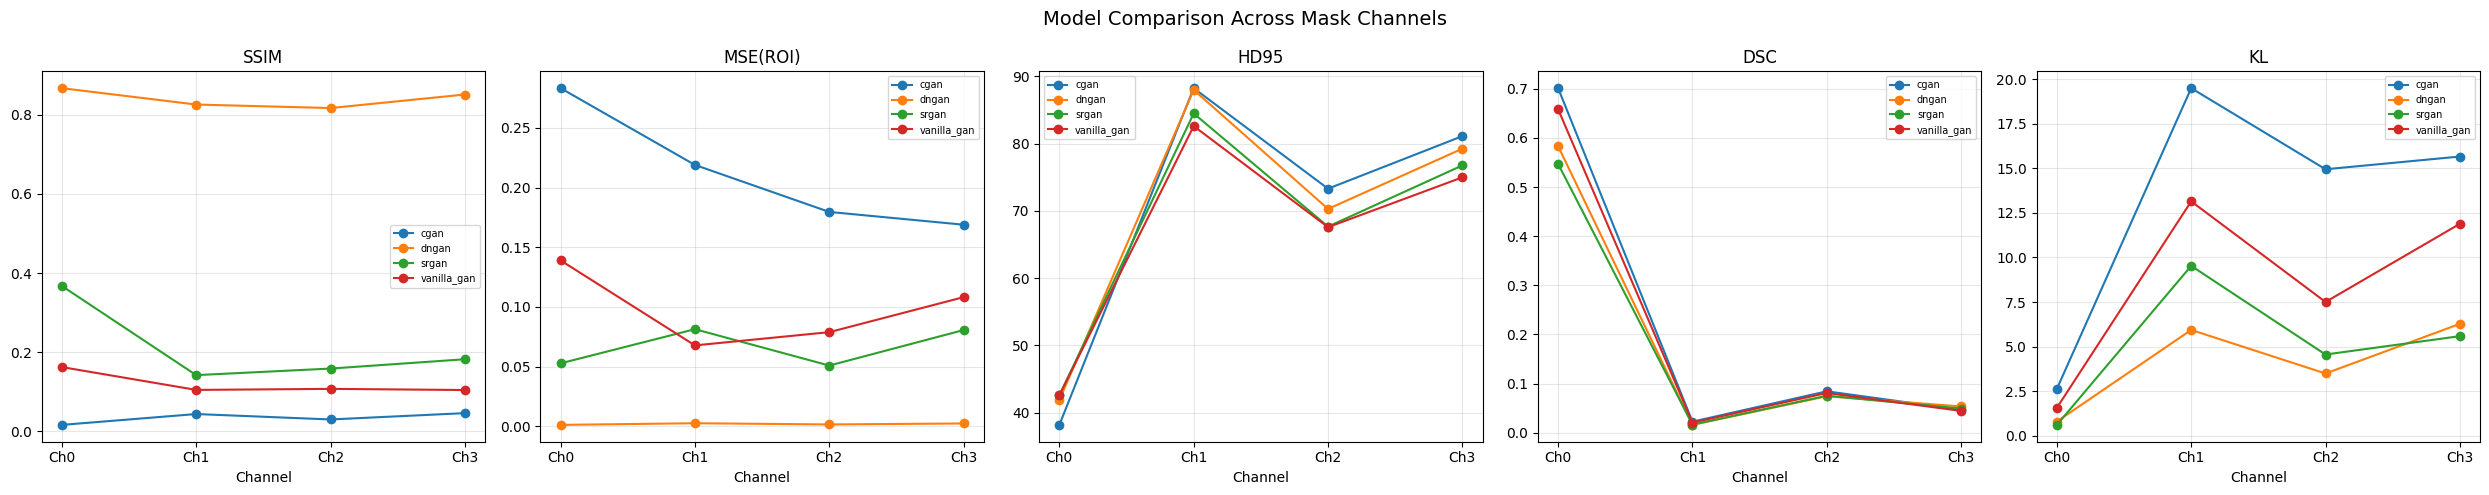

✓ Saved to F:\shn\results\comparison.png


In [12]:
import matplotlib.pyplot as plt

if rows:
    metrics=["SSIM","MSE(ROI)","HD95","DSC","KL"]
    fig,axes=plt.subplots(1,len(metrics),figsize=(25,5))
    channels=sorted({row["Channel"] for row in rows})
    models=sorted({row["Model"] for row in rows})
    colors=plt.cm.tab10(range(len(models)))
    
    for ax,met in zip(axes,metrics):
        for i,mod in enumerate(models):
            vals=[row[met] for row in rows if row["Model"]==mod]
            ax.plot(channels,vals,marker="o",label=mod,color=colors[i])
        ax.set_title(met); ax.set_xlabel("Channel"); ax.legend(fontsize=7)
        ax.grid(True,alpha=0.3)
    
    plt.suptitle("Model Comparison Across Mask Channels",fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS,"comparison.png"),dpi=150)
    plt.show()
    print(f"✓ Saved to {os.path.join(RESULTS,'comparison.png')}")